/storage/miniconda3/lib/python3.13/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: end is not sorted. Cannot add metadata to unsorted end times. Sorting it and dropping metadata.
  data = nap.IntervalSet(df)
/storage/miniconda3/lib/python3.13/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: Some starts precede the previous end. Joining them!
  data = nap.IntervalSet(df)
/storage/miniconda3/lib/python3.13/site-packages/pynapple/io/interface_nwb.py:133: UserWarning: epochs have changed, dropping metadata.
  data = nap.IntervalSet(df)


loaded sub-M05/sub-M05_ses-20240731T100000_behavior+ecephys.nwb in 2.5s
1. mount and inventory
package root: /notebooks/CumulantDynamicsGuiltByAssociation/Hydrangea_demo
data mount:   /storage/dandi_downloads
16 recordings | 4 subjects | 2.6 GB

last behaviour session per subject:
subject         session       date  size_mb                                                     file
    M01 20240318T100000 2024-03-18    190.0 sub-M01/sub-M01_ses-20240318T100000_behavior+ecephys.nwb
    M02 20240318T100000 2024-03-18    112.5 sub-M02/sub-M02_ses-20240318T100000_behavior+ecephys.nwb
    M03 20240624T100000 2024-06-24    229.3 sub-M03/sub-M03_ses-20240624T100000_behavior+ecephys.nwb
    M05 20240731T100000 2024-07-31    239.5 sub-M05/sub-M05_ses-20240731T100000_behavior+ecephys.nwb

2. last-day survey, ranked by units active in the maze
subject         session       date  n_units  n_units_active_in_maze  maze_min  n_regions                     lfp_key
    M05 20240731T100000 2024-07-31      

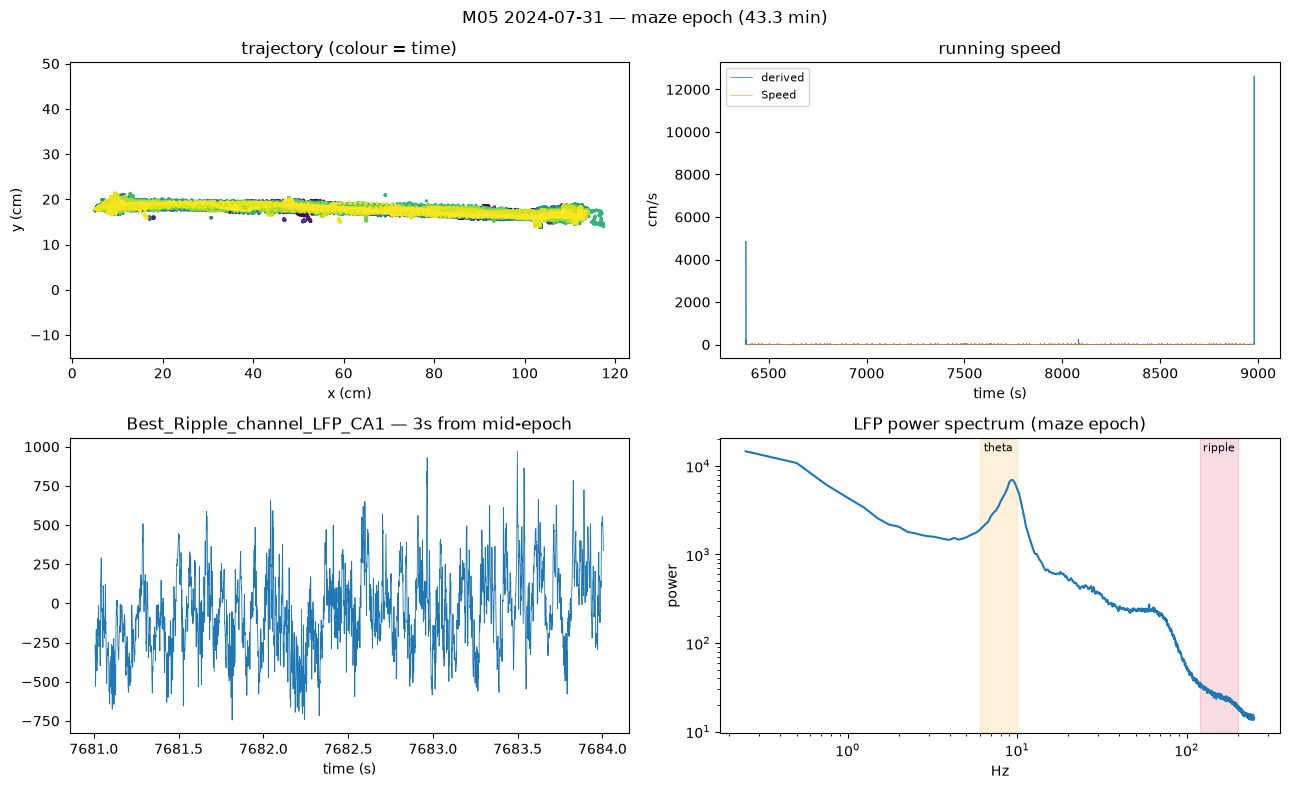

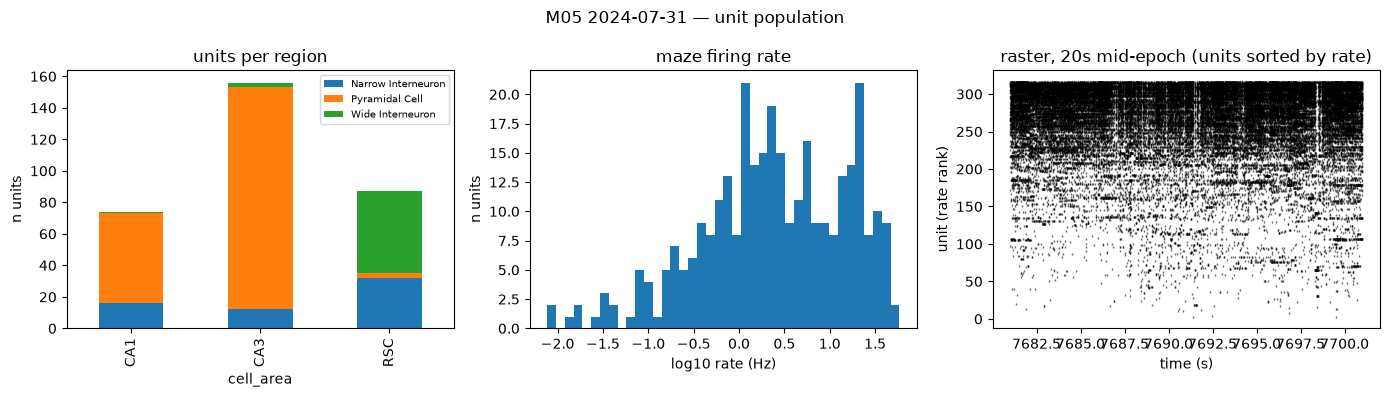


10. ready for stage 2 (UMAP)
bundle keys: subject, session, date, path, nwb, nwb_keys, maze_ep, maze_s, spikes, spikes_all, unit_meta, pos_t, pos_xy, pos_hz, speed_key, speed_nwb_t, speed_nwb_v, speed_der_t, speed_der_v, lfp_key, lfp_t, lfp_v, lfp_hz, sleep_key, sleep_states, load_s
  bundle['spikes']      pynapple TsGroup, restricted to the maze epoch
  bundle['unit_meta']   per-unit DataFrame incl. n_spikes_maze, rate_maze_hz
  bundle['pos_t' / 'pos_xy']       behaviour on the maze clock
  bundle['speed_der_t' / '_v']     derived speed; 'speed_nwb_*' is the shipped one
  bundle['lfp_t' / 'lfp_v' / 'lfp_hz']   CA1 LFP over the same epoch
  bundle['sleep_states']           raw sleep-state object

planned UMAP: 3 components, 50 ms bins -> observation matrix ~51934 bins x 317 units
umap-learn NOT installed — `pip install umap-learn` before stage 2


In [1]:
"""UMAP test on the last recording day — STAGE 1: gather the data.

Paste the whole file into one notebook cell and run it. It is written to be a
single script: no `# %%` splits, no files written, everything reported with
print() and plt.show().

What it does
    1. inventory the data mount (same paths as test_hydan_obj.py)
    2. take the LAST behaviour session of every subject and count units
    3. pick the subject whose last day has the most units
    4. load that session's maze epoch: spikes, unit metadata, position,
       speed (shipped + derived), CA1 LFP, sleep states
    5. print and plot all of it so we can see what we are working with

Stage 2 (the UMAP itself, down to 3 components) is not here yet — the bundle
this builds is the input to it. `load_session_bundle()` takes any inventory
row, so extending from one mouse to every mouse's last day later is a loop, not
a rewrite.

The hydrangea package is used only for two small helpers (unit metadata
extraction, speed from position); nothing here depends on the analysis object.
"""

import os
import re
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap

# =============================================================================
# CONFIG
# =============================================================================

# Same discovery + mount as test_hydan_obj.py: works from the repo root, from
# Hydrangea_demo/, locally or on the cloud box.
DOWNLOAD_DIR = Path(os.environ.get("HYDRANGEA_DATA_DIR", "/storage/dandi_downloads")).resolve()

LFP_SNIPPET_S = 3.0        # length of the raw-LFP snippet in the diagnostic plot
PSD_MAX_HZ = 250.0         # x-limit for the LFP power spectrum panel
SHOW_DIAGNOSTICS = True    # SCRIPT-CONSTRUCTION ONLY — see the note at step 4

# Stage 2 settings, fixed now so the gather step can check the environment can
# actually run them. The embedding goes down to 3 components.
UMAP_N_COMPONENTS = 3
UMAP_BIN_SIZE_S = 0.050    # observation bin for the spike matrix UMAP will see
UMAP_RANDOM_STATE = 0


def find_package_root(start):
    """Walk up from `start` looking for the hybrid_dynamics_core package."""
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "hybrid_dynamics_core").is_dir():
            return candidate
        nested = candidate / "Hydrangea_demo"
        if (nested / "hybrid_dynamics_core").is_dir():
            return nested
    return start


PACKAGE_ROOT = find_package_root(Path.cwd())
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT))

from hybrid_dynamics_core.metadata import extract_unit_metadata  # noqa: E402
from hybrid_dynamics_core.spiking_and_behaviour_eda import (  # noqa: E402
    compute_speed_from_position,
    infer_sampling_rate_hz,
)


# =============================================================================
# STEP 1 — inventory the mount
# =============================================================================
# Identifiers come out of the BIDS-style filename:
#     sub-M01_ses-20240313T100000_behavior+ecephys.nwb
# The session stamp sorts lexicographically in time order, so "last day" is
# just the max session string per subject.


def parse_session_name(nwb_path, root):
    """Subject, session, date, and modalities from an NWB filename."""
    nwb_path = Path(nwb_path)
    stem = nwb_path.stem

    subject = re.search(r"(?:^|_)sub-([^_]+)", stem)
    session = re.search(r"(?:^|_)ses-([^_]+)", stem)
    subject = subject.group(1) if subject else nwb_path.parent.name.replace("sub-", "")
    session = session.group(1) if session else "unknown"

    date = None
    if "T" in session:
        raw_date = session.split("T", 1)[0]
        if len(raw_date) == 8 and raw_date.isdigit():
            date = f"{raw_date[:4]}-{raw_date[4:6]}-{raw_date[6:]}"

    modalities = stem.split("_")[-1].split("+")
    return {
        "subject": subject,
        "session": session,
        "date": date,
        "modalities": "+".join(modalities),
        "has_behavior": "behavior" in modalities,
        "size_mb": round(nwb_path.stat().st_size / 1e6, 1),
        "file": str(nwb_path.relative_to(root)),
    }


def session_inventory(root):
    """Table of every NWB recording under the data mount."""
    rows = [parse_session_name(p, root) for p in sorted(Path(root).rglob("*.nwb"))]
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["subject", "session"]).reset_index(drop=True)


def last_day_per_subject(inventory):
    """The latest behaviour session for each subject, one row per subject."""
    behavior = inventory[inventory["has_behavior"]]
    idx = behavior.groupby("subject")["session"].idxmax()
    return behavior.loc[idx].sort_values("subject").reset_index(drop=True)


inventory = session_inventory(DOWNLOAD_DIR)
last_days = last_day_per_subject(inventory)


# =============================================================================
# STEP 2 — loaders
# =============================================================================
# Two helpers so the survey and the full load share one definition of what the
# maze epoch is and where each signal lives in the NWB.


def find_key(nwb, *patterns):
    """First NWB key matching any of the (case-insensitive) substrings."""
    keys = list(nwb.keys())
    for pattern in patterns:
        for key in keys:
            if pattern.lower() in key.lower():
                return key
    return None


def maze_epoch_from(position):
    """Analysis epoch = the position-tracked span (same rule as the demo)."""
    return nap.IntervalSet(start=float(position.index[0]), end=float(position.index[-1]))


def as_time_values(obj):
    """Timestamps + values as plain numpy, forcing any lazy NWB load."""
    t = np.asarray(obj.index.values, dtype=float)
    v = np.asarray(obj.values, dtype=float)
    return t, (v.ravel() if v.ndim == 2 and v.shape[1] == 1 else v)


def survey_row(row):
    """Unit counts and epoch length for one session, without keeping the file."""
    nwb = nap.load_file(str((DOWNLOAD_DIR / row["file"]).resolve()))
    spikes = nwb["units"]
    position = nwb["Position"]
    maze_ep = maze_epoch_from(position)
    spikes_maze = spikes.restrict(maze_ep)
    n_active = int(sum(len(spikes_maze[u]) > 0 for u in spikes_maze.index))

    meta = extract_unit_metadata(spikes)
    region_col = "cell_area" if "cell_area" in meta.columns else None

    return {
        "subject": row["subject"],
        "session": row["session"],
        "date": row["date"],
        "n_units": len(spikes),
        "n_units_active_in_maze": n_active,
        "maze_min": round(float(maze_ep.tot_length() / 60), 1),
        "n_regions": int(meta[region_col].nunique()) if region_col else 0,
        "lfp_key": find_key(nwb, "lfp"),
        "nwb_keys": ", ".join(nwb.keys()),
        "file": row["file"],
    }


def load_session_bundle(row, verbose=True):
    """Everything the UMAP needs for one session, restricted to the maze epoch.

    Returns a dict rather than an object: this is a scratch stage, and a dict
    keeps the notebook namespace explicit about what was actually loaded.
    """
    path = (DOWNLOAD_DIR / row["file"]).resolve()
    t0 = time.perf_counter()
    nwb = nap.load_file(str(path))

    # --- spikes + unit metadata --------------------------------------------
    spikes_all = nwb["units"]
    position_all = nwb["Position"]
    maze_ep = maze_epoch_from(position_all)
    maze_s = float(maze_ep.tot_length())
    spikes = spikes_all.restrict(maze_ep)

    unit_meta = extract_unit_metadata(spikes_all)
    n_spikes_maze = np.array([len(spikes[u]) for u in spikes.index], dtype=int)
    unit_meta = unit_meta.reindex(np.asarray(spikes.index))
    unit_meta["n_spikes_maze"] = n_spikes_maze
    unit_meta["rate_maze_hz"] = n_spikes_maze / maze_s

    # --- behaviour ----------------------------------------------------------
    position = position_all.restrict(maze_ep)
    pos_t = np.asarray(position.index.values, dtype=float)
    pos_xy = np.column_stack([
        np.asarray(position["x"].values, dtype=float),
        np.asarray(position["y"].values, dtype=float),
    ])

    speed_key = find_key(nwb, "speed")
    speed_nwb_t, speed_nwb_v = (None, None)
    if speed_key is not None:
        speed_nwb_t, speed_nwb_v = as_time_values(nwb[speed_key].restrict(maze_ep))
    # derived here too so the shipped channel can be sanity-checked against it
    speed_der_t, speed_der_v = compute_speed_from_position(position, columns=("x", "y"),
                                                           smooth_window_s=0.25)

    # --- LFP ----------------------------------------------------------------
    lfp_key = find_key(nwb, "lfp")
    lfp_t, lfp_v, lfp_hz = None, None, None
    if lfp_key is not None:
        lfp_t, lfp_v = as_time_values(nwb[lfp_key].restrict(maze_ep))
        lfp_hz = infer_sampling_rate_hz(lfp_t)

    # --- sleep states (kept raw; shape varies by dataset) -------------------
    sleep_key = find_key(nwb, "sleepstate", "sleep")
    sleep_states = nwb[sleep_key] if sleep_key is not None else None

    bundle = {
        "subject": row["subject"],
        "session": row["session"],
        "date": row["date"],
        "path": path,
        "nwb": nwb,
        "nwb_keys": list(nwb.keys()),
        "maze_ep": maze_ep,
        "maze_s": maze_s,
        "spikes": spikes,
        "spikes_all": spikes_all,
        "unit_meta": unit_meta,
        "pos_t": pos_t,
        "pos_xy": pos_xy,
        "pos_hz": infer_sampling_rate_hz(pos_t),
        "speed_key": speed_key,
        "speed_nwb_t": speed_nwb_t,
        "speed_nwb_v": speed_nwb_v,
        "speed_der_t": speed_der_t,
        "speed_der_v": speed_der_v,
        "lfp_key": lfp_key,
        "lfp_t": lfp_t,
        "lfp_v": lfp_v,
        "lfp_hz": lfp_hz,
        "sleep_key": sleep_key,
        "sleep_states": sleep_states,
        "load_s": time.perf_counter() - t0,
    }
    if verbose:
        print(f"loaded {row['file']} in {bundle['load_s']:.1f}s")
    return bundle


# =============================================================================
# STEP 3 — survey the last days, pick the mouse, load it
# =============================================================================

survey = pd.DataFrame([survey_row(r) for _, r in last_days.iterrows()])
survey = survey.sort_values("n_units_active_in_maze", ascending=False).reset_index(drop=True)

chosen_row = survey.iloc[0]
bundle = load_session_bundle(
    last_days[last_days["subject"] == chosen_row["subject"]].iloc[0]
)


# =============================================================================
# STEP 4 — SCRIPT-CONSTRUCTION ONLY: gather + display
# -----------------------------------------------------------------------------
# NOTE: this whole block exists only so we can SEE the data while building the
# script — it prints and plots what was loaded above and computes nothing that
# anything downstream needs. Comment it out (or set SHOW_DIAGNOSTICS = False)
# once the UMAP stage is written.
# =============================================================================

if SHOW_DIAGNOSTICS:
    b = bundle
    rule = "=" * 78

    # --- 1. where we are ----------------------------------------------------
    print(rule)
    print("1. mount and inventory")
    print(rule)
    print("package root:", PACKAGE_ROOT)
    print("data mount:  ", DOWNLOAD_DIR)
    print(f"{len(inventory)} recordings | {inventory['subject'].nunique()} subjects | "
          f"{inventory['size_mb'].sum() / 1000:.1f} GB")
    print("\nlast behaviour session per subject:")
    print(last_days[["subject", "session", "date", "size_mb", "file"]].to_string(index=False))

    # --- 2. the survey that picked the mouse --------------------------------
    print("\n" + rule)
    print("2. last-day survey, ranked by units active in the maze")
    print(rule)
    print(survey[["subject", "session", "date", "n_units", "n_units_active_in_maze",
                  "maze_min", "n_regions", "lfp_key"]].to_string(index=False))
    print(f"\n-> chosen: {b['subject']} / {b['session']} ({b['date']})")
    print("   NWB keys:", b["nwb_keys"])

    # --- 3. what each NWB object actually is --------------------------------
    print("\n" + rule)
    print("3. NWB object types")
    print(rule)
    for key in b["nwb_keys"]:
        try:
            obj = b["nwb"][key]
            shape = getattr(obj, "shape", None)
            n = len(obj)
            print(f"  {key:32s} {type(obj).__name__:12s} len={n:<10d} shape={shape}")
        except Exception as exc:  # some NWB fields do not load through pynapple
            print(f"  {key:32s} <could not load: {type(exc).__name__}: {exc}>")

    # --- 4. epoch + spiking -------------------------------------------------
    print("\n" + rule)
    print("4. maze epoch and spiking")
    print(rule)
    rec_start = float(min(b["spikes_all"][u].index[0]
                          for u in b["spikes_all"].index if len(b["spikes_all"][u])))
    rec_end = float(max(b["spikes_all"][u].index[-1]
                        for u in b["spikes_all"].index if len(b["spikes_all"][u])))
    print(f"recording span : {rec_start:8.1f} - {rec_end:8.1f}s  ({(rec_end - rec_start) / 60:.1f} min)")
    print(f"maze epoch     : {float(b['maze_ep'].start[0]):8.1f} - "
          f"{float(b['maze_ep'].end[0]):8.1f}s  ({b['maze_s'] / 60:.1f} min)")
    print(f"units          : {len(b['spikes_all'])} total, "
          f"{int((b['unit_meta']['n_spikes_maze'] > 0).sum())} with spikes in the maze")
    print(f"spikes in maze : {int(b['unit_meta']['n_spikes_maze'].sum()):,}")

    # --- 5. unit metadata ---------------------------------------------------
    print("\n" + rule)
    print("5. unit metadata")
    print(rule)
    meta = b["unit_meta"]
    print(f"shape {meta.shape} | columns: {', '.join(meta.columns)}")
    print("\nhead:")
    print(meta.head(5).to_string())
    if {"cell_area", "cell_type"} <= set(meta.columns):
        print("\nunits by region x cell_type:")
        print(pd.crosstab(meta["cell_area"], meta["cell_type"], margins=True, margins_name="Total"))
    print("\nmaze firing rate (Hz) by region:")
    if "cell_area" in meta.columns:
        print(meta.groupby("cell_area")["rate_maze_hz"]
              .describe()[["count", "min", "50%", "mean", "max"]].round(3).to_string())
    print("\ndtypes of the non-numeric columns:")
    print(meta.dtypes[meta.dtypes == object].to_string() or "  (none)")

    # --- 6. behaviour -------------------------------------------------------
    print("\n" + rule)
    print("6. behaviour")
    print(rule)
    print(f"position     : {len(b['pos_t'])} samples @ {b['pos_hz']:.1f} Hz | "
          f"x {b['pos_xy'][:, 0].min():.1f}-{b['pos_xy'][:, 0].max():.1f}, "
          f"y {b['pos_xy'][:, 1].min():.1f}-{b['pos_xy'][:, 1].max():.1f} cm")
    print(f"NaNs in position: x={int(np.isnan(b['pos_xy'][:, 0]).sum())}, "
          f"y={int(np.isnan(b['pos_xy'][:, 1]).sum())}")
    if b["speed_nwb_v"] is not None:
        print(f"speed ('{b['speed_key']}', shipped): {len(b['speed_nwb_v'])} samples @ "
              f"{infer_sampling_rate_hz(b['speed_nwb_t']):.1f} Hz | "
              f"median {np.nanmedian(b['speed_nwb_v']):.2f}, max {np.nanmax(b['speed_nwb_v']):.1f}")
    print(f"speed (derived from position): median {np.median(b['speed_der_v']):.2f}, "
          f"max {b['speed_der_v'].max():.1f} cm/s")
    if b["speed_nwb_v"] is not None and len(b["speed_nwb_v"]) == len(b["speed_der_v"]):
        ok = np.isfinite(b["speed_nwb_v"]) & np.isfinite(b["speed_der_v"])
        print(f"corr(shipped, derived) = {np.corrcoef(b['speed_nwb_v'][ok], b['speed_der_v'][ok])[0, 1]:.3f}")

    # --- 7. LFP -------------------------------------------------------------
    print("\n" + rule)
    print("7. LFP")
    print(rule)
    if b["lfp_v"] is None:
        print("no LFP-like key found in this NWB")
    else:
        gaps = np.diff(b["lfp_t"])
        print(f"key           : {b['lfp_key']}")
        print(f"samples       : {len(b['lfp_v']):,} @ {b['lfp_hz']:.1f} Hz "
              f"({len(b['lfp_v']) / b['lfp_hz'] / 60:.1f} min)")
        print(f"maze coverage : {len(b['lfp_v']) / b['lfp_hz'] / b['maze_s'] * 100:.1f}% of the epoch")
        print(f"span          : {b['lfp_t'][0]:.1f} - {b['lfp_t'][-1]:.1f}s")
        print(f"sample gaps   : median {np.median(gaps) * 1e3:.3f} ms, "
              f"max {gaps.max() * 1e3:.3f} ms, "
              f"{int((gaps > 2 * np.median(gaps)).sum())} gaps > 2x median")
        print(f"amplitude     : mean {np.nanmean(b['lfp_v']):.1f}, sd {np.nanstd(b['lfp_v']):.1f}, "
              f"range {np.nanmin(b['lfp_v']):.1f} to {np.nanmax(b['lfp_v']):.1f} "
              f"| NaNs {int(np.isnan(b['lfp_v']).sum())}")

    # --- 8. sleep states ----------------------------------------------------
    print("\n" + rule)
    print("8. sleep states")
    print(rule)
    ss = b["sleep_states"]
    if ss is None:
        print("no sleep-state key found")
    else:
        print(f"key: {b['sleep_key']} | type: {type(ss).__name__}")
        try:
            if isinstance(ss, dict):
                for name, iset in ss.items():
                    print(f"  {name:20s} {len(iset)} intervals, "
                          f"{float(iset.tot_length()) / 60:.1f} min total")
            else:
                print(f"  {len(ss)} intervals, {float(ss.tot_length()) / 60:.1f} min total")
                inside = ss.intersect(b["maze_ep"])
                print(f"  overlapping the maze epoch: {len(inside)} intervals, "
                      f"{float(inside.tot_length()) / 60:.1f} min")
                meta_ss = getattr(ss, "metadata", None)
                if isinstance(meta_ss, pd.DataFrame) and len(meta_ss):
                    print("  metadata columns:", ", ".join(meta_ss.columns))
                    print(meta_ss.head(10).to_string())
        except Exception as exc:
            print(f"  <could not summarize: {type(exc).__name__}: {exc}>")

    # --- 9. plots -----------------------------------------------------------
    # One figure for behaviour + LFP, one for the unit population.
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(f"{b['subject']} {b['date']} — maze epoch ({b['maze_s'] / 60:.1f} min)")

    ax = axes[0, 0]
    ax.scatter(b["pos_xy"][:, 0], b["pos_xy"][:, 1], c=b["pos_t"], s=2, cmap="viridis")
    ax.set_title("trajectory (colour = time)")
    ax.set_xlabel("x (cm)")
    ax.set_ylabel("y (cm)")
    ax.set_aspect("equal", adjustable="datalim")

    ax = axes[0, 1]
    ax.plot(b["speed_der_t"], b["speed_der_v"], lw=0.5, label="derived")
    if b["speed_nwb_v"] is not None:
        ax.plot(b["speed_nwb_t"], b["speed_nwb_v"], lw=0.5, alpha=0.7, label=b["speed_key"])
    ax.set_title("running speed")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("cm/s")
    ax.legend(fontsize=8)

    ax = axes[1, 0]
    if b["lfp_v"] is not None:
        n_snip = int(LFP_SNIPPET_S * b["lfp_hz"])
        start = len(b["lfp_v"]) // 2
        sl = slice(start, start + n_snip)
        ax.plot(b["lfp_t"][sl], b["lfp_v"][sl], lw=0.6)
        ax.set_title(f"{b['lfp_key']} — {LFP_SNIPPET_S:.0f}s from mid-epoch")
        ax.set_xlabel("time (s)")
    else:
        ax.text(0.5, 0.5, "no LFP", ha="center", transform=ax.transAxes)

    ax = axes[1, 1]
    if b["lfp_v"] is not None:
        try:
            from scipy.signal import welch
            freq, psd = welch(b["lfp_v"], fs=b["lfp_hz"], nperseg=int(4 * b["lfp_hz"]))
        except Exception:  # scipy missing — plain periodogram on a slice
            seg = b["lfp_v"][: int(60 * b["lfp_hz"])]
            psd = np.abs(np.fft.rfft(seg)) ** 2 / len(seg)
            freq = np.fft.rfftfreq(len(seg), 1 / b["lfp_hz"])
        keep = (freq > 0) & (freq <= PSD_MAX_HZ)
        ax.loglog(freq[keep], psd[keep])
        for band, lo, hi in [("theta", 6, 10), ("ripple", 120, 200)]:
            ax.axvspan(lo, hi, alpha=0.15, color="orange" if band == "theta" else "crimson")
            ax.text(np.sqrt(lo * hi), psd[keep].max(), band, ha="center", fontsize=8)
        ax.set_title("LFP power spectrum (maze epoch)")
        ax.set_xlabel("Hz")
        ax.set_ylabel("power")
    else:
        ax.text(0.5, 0.5, "no LFP", ha="center", transform=ax.transAxes)

    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"{b['subject']} {b['date']} — unit population")

    ax = axes[0]
    if "cell_area" in meta.columns and "cell_type" in meta.columns:
        pd.crosstab(meta["cell_area"], meta["cell_type"]).plot(kind="bar", stacked=True, ax=ax)
        ax.legend(fontsize=7)
    else:
        ax.text(0.5, 0.5, "no region/cell_type metadata", ha="center", transform=ax.transAxes)
    ax.set_title("units per region")
    ax.set_ylabel("n units")

    ax = axes[1]
    rates = meta["rate_maze_hz"].replace(0, np.nan).dropna()
    ax.hist(np.log10(rates), bins=40)
    ax.set_title("maze firing rate")
    ax.set_xlabel("log10 rate (Hz)")
    ax.set_ylabel("n units")

    ax = axes[2]
    # raster preview: 20s from mid-epoch, units ordered by rate
    order = meta["rate_maze_hz"].sort_values().index
    t_mid = float(b["maze_ep"].start[0]) + b["maze_s"] / 2
    win = nap.IntervalSet(start=t_mid, end=t_mid + 20)
    for row_i, unit in enumerate(order):
        ts = b["spikes"][unit].restrict(win).index.values
        if len(ts):
            ax.plot(ts, np.full(len(ts), row_i), "|", ms=2, color="k", alpha=0.6)
    ax.set_title("raster, 20s mid-epoch (units sorted by rate)")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("unit (rate rank)")

    fig.tight_layout()
    plt.show()

    # --- 10. what is now in the namespace -----------------------------------
    print("\n" + rule)
    print("10. ready for stage 2 (UMAP)")
    print(rule)
    print("bundle keys:", ", ".join(bundle.keys()))
    print("  bundle['spikes']      pynapple TsGroup, restricted to the maze epoch")
    print("  bundle['unit_meta']   per-unit DataFrame incl. n_spikes_maze, rate_maze_hz")
    print("  bundle['pos_t' / 'pos_xy']       behaviour on the maze clock")
    print("  bundle['speed_der_t' / '_v']     derived speed; 'speed_nwb_*' is the shipped one")
    print("  bundle['lfp_t' / 'lfp_v' / 'lfp_hz']   CA1 LFP over the same epoch")
    print("  bundle['sleep_states']           raw sleep-state object")

    # stage-2 environment check: is umap-learn installed, and how big will the
    # observation matrix be at the bin size we plan to embed at?
    n_bins = int(np.floor(b["maze_s"] / UMAP_BIN_SIZE_S))
    n_units_active = int((meta["n_spikes_maze"] > 0).sum())
    print(f"\nplanned UMAP: {UMAP_N_COMPONENTS} components, {UMAP_BIN_SIZE_S * 1e3:.0f} ms bins "
          f"-> observation matrix ~{n_bins} bins x {n_units_active} units")
    try:
        import umap  # noqa: F401
        print(f"umap-learn {umap.__version__} available")
    except ImportError:
        print("umap-learn NOT installed — `pip install umap-learn` before stage 2")
